In [4]:
#generating geometry
import numpy as np




E = 210e9      # Young's modulus
nu = 0.3       # Poisson's ratio
t = 0.01       # thickness
bx = 0         #Body force along x
by = 0         #Body force along y direction


#defining mesh generating function

import matplotlib.pyplot as plt


# MESH GENERATION FUNCTION

def generate_mesh(Lx, Ly, nx, ny):

    dx = Lx / nx
    dy = Ly / ny

    nodes = []
    for j in range(ny + 1):
        for i in range(nx + 1):
            nodes.append([i * dx, j * dy])

    nodes = np.array(nodes)

    elements = []
    for j in range(ny):
        for i in range(nx):
            n1 = j*(nx+1) + i
            n2 = n1 + 1
            n3 = n2 + (nx+1)
            n4 = n1 + (nx+1)
            elements.append([n1, n2, n3, n4])

    elements = np.array(elements)

    return nodes, elements, dx, dy




#code for elemental stiffness matrix , body force vector , traction force vector


# Gauss Points
gauss_pts = [(-1/np.sqrt(3), -1/np.sqrt(3)),
             ( 1/np.sqrt(3), -1/np.sqrt(3)),
             ( 1/np.sqrt(3),  1/np.sqrt(3)),
             (-1/np.sqrt(3),  1/np.sqrt(3))]


def element_stiffness(coords, E, nu, t):
    
    # coords in array containing 4 coordinates of the element
    
    # Material matrix (plane stress)
    D = (E/(1 - nu**2)) * np.array([
        [1, nu, 0],
        [nu, 1, 0],
        [0, 0, (1-nu)/2]
    ])

    Ke = np.zeros((8,8))

    for xi, eta in gauss_pts:

        # Shape function derivatives
        dN_dxi = 0.25 * np.array([
            [-(1-eta), -(1-xi)],
            [ (1-eta), -(1+xi)],
            [ (1+eta),  (1+xi)],
            [-(1+eta),  (1-xi)]
        ])

        # Jacobian
        J = np.zeros((2,2))
        for i in range(4):
            J += np.outer(dN_dxi[i], coords[i])

        detJ = np.linalg.det(J)
        invJ = np.linalg.inv(J)

        # B matrix
        B = np.zeros((3,8))
        for i in range(4):
            dN = invJ @ dN_dxi[i]

            B[0,2*i]   = dN[0]
            B[1,2*i+1] = dN[1]
            B[2,2*i]   = dN[1]
            B[2,2*i+1] = dN[0]

        Ke += B.T @ D @ B * detJ * t

    return Ke 

# Body force vector
def element_body_force(coords, bx, by, t):
    Fe = np.zeros(8)

    for xi, eta in gauss_pts:

        # Shape functions
        N = 0.25 * np.array([
            (1-xi)*(1-eta),
            (1+xi)*(1-eta),
            (1+xi)*(1+eta),
            (1-xi)*(1+eta)
        ])

        # Derivatives for Jacobian
        dN_dxi = 0.25 * np.array([
            [-(1-eta), -(1-xi)],
            [ (1-eta), -(1+xi)],
            [ (1+eta),  (1+xi)],
            [-(1+eta),  (1-xi)]
        ])

        # Jacobian
        J = np.zeros((2,2))
        for i in range(4):
            J += np.outer(dN_dxi[i], coords[i])

        detJ = np.linalg.det(J)

        # Assemble
        for i in range(4):
            Fe[2*i]   += N[i] * bx * detJ * t
            Fe[2*i+1] += N[i] * by * detJ * t

    return Fe



# traction vector 
def element_traction(coords, edge, tx, ty, t):
    """
    edge: 0→(1-2), 1→(2-3), 2→(3-4), 3→(4-1)
    """

    Fe = np.zeros(8)

    # Edge node pairs
    edge_nodes = [(0,1), (1,2), (2,3), (3,0)]
    n1, n2 = edge_nodes[edge]

    x1, x2 = coords[n1], coords[n2]

    # Length of edge
    L = np.linalg.norm(x2 - x1)

    # 1D Gauss points
    gauss_1D = [-1/np.sqrt(3), 1/np.sqrt(3)]

    for xi in gauss_1D:

        # 1D shape functions
        N_edge = np.array([(1-xi)/2, (1+xi)/2])

        for i, node in enumerate([n1, n2]):
            Fe[2*node]   += N_edge[i] * tx * (L/2) * t
            Fe[2*node+1] += N_edge[i] * ty * (L/2) * t

    return Fe


#Solve
def solve_fem(nodes, elements):

    n_nodes = len(nodes)
    ndof = 2 * n_nodes

    K_global = np.zeros((ndof, ndof))
    F_global = np.zeros(ndof)

    # Assembly
    for e in range(len(elements)):

        node_ids = elements[e]
        coords = nodes[node_ids]

        Ke = element_stiffness(coords, E, nu, t)
        Fe = element_body_force(coords, bx, by, t)

        # traction on top edge
        y_coords = coords[:,1]
        if np.allclose(y_coords[2:], Ly):
            Fe += element_traction(coords, edge=2, tx=0, ty=-10000, t=t)

        # DOF mapping
        dof = []
        for n in node_ids:
            dof.extend([2*n, 2*n+1])

        # Assemble
        for i in range(8):
            for j in range(8):
                K_global[dof[i], dof[j]] += Ke[i, j]

        for i in range(8):
            F_global[dof[i]] += Fe[i]
        

    # Boundary condition (fix left edge)
    fixed_dof = []
    for i, (x, y) in enumerate(nodes):
        if np.isclose(x, 0):
            fixed_dof.extend([2*i, 2*i+1])

    free_dof = [i for i in range(ndof) if i not in fixed_dof]

    # Reduce system
    K_reduced = K_global[np.ix_(free_dof, free_dof)]
    F_reduced = F_global[free_dof]

    
    U = np.zeros(ndof)
    U[free_dof] = np.linalg.solve(K_reduced, F_reduced)

    return U , K_global
    
    

In [5]:
import numpy as np
import matplotlib.pyplot as plt


# Plot shear stress and shear strain through thickness


def plot_shear_stress_strain_through_thickness(
        nodes,
        elements,
        U,
        x_location,
        E,
        nu):

    
    # Material matrix (plane stress)
   
    D = (E / (1 - nu**2)) * np.array([
        [1,     nu,          0],
        [nu,    1,           0],
        [0,     0,   (1-nu)/2]
    ])

    y_values = []

    tau_xy_values = []

    gamma_xy_values = []

    
    # Loop over elements
  
    for elem in elements:

        coords = nodes[elem]

        x_elem = coords[:,0]

        # Select elements near x_location
        if x_location >= min(x_elem) and x_location <= max(x_elem):

            xi = 0
            eta = 0

            # Shape function derivatives
            dN_dxi = np.array([
                -0.25*(1-eta),
                 0.25*(1-eta),
                 0.25*(1+eta),
                -0.25*(1+eta)
            ])

            dN_deta = np.array([
                -0.25*(1-xi),
                -0.25*(1+xi),
                 0.25*(1+xi),
                 0.25*(1-xi)
            ])

           
            # Jacobian
            
            J = np.zeros((2,2))

            for i in range(4):

                J[0,0] += dN_dxi[i]  * coords[i,0]
                J[0,1] += dN_deta[i] * coords[i,0]

                J[1,0] += dN_dxi[i]  * coords[i,1]
                J[1,1] += dN_deta[i] * coords[i,1]

            invJ = np.linalg.inv(J)

            
            # Derivatives wrt x,y
         
            dN = np.zeros((4,2))

            for i in range(4):

                dN[i,:] = invJ @ np.array([
                    dN_dxi[i],
                    dN_deta[i]
                ])

           
            # B matrix
                
            B = np.zeros((3,8))

            for i in range(4):

                B[0,2*i]   = dN[i,0]

                B[1,2*i+1] = dN[i,1]

                B[2,2*i]   = dN[i,1]

                B[2,2*i+1] = dN[i,0]

            
            # Element displacement vector
            
            ue = np.zeros(8)

            for i,node in enumerate(elem):

                ue[2*i]   = U[2*node]

                ue[2*i+1] = U[2*node+1]

            
            # Strain and stress
           
            strain = B @ ue

            stress = D @ strain

            gamma_xy = strain[2]

            tau_xy = stress[2]

            # Element center y-coordinate
            y_center = np.mean(coords[:,1])

            y_values.append(y_center)

            gamma_xy_values.append(gamma_xy)

            tau_xy_values.append(tau_xy)

    
    # Sort data
    
    y_values = np.array(y_values)

    gamma_xy_values = np.array(gamma_xy_values)

    tau_xy_values = np.array(tau_xy_values)

    sort_idx = np.argsort(y_values)

    y_values = y_values[sort_idx]

    gamma_xy_values = gamma_xy_values[sort_idx]

    tau_xy_values = tau_xy_values[sort_idx]

    
    # Plot shear stress
    
    plt.figure(figsize=(6,5))

    plt.plot(tau_xy_values, y_values, 'o-', linewidth=2)

    plt.xlabel(r"Shear Stress ($\tau_{xy}$) [Pa]")

    plt.ylabel("Thickness Direction (y)")

    plt.title(f"Shear Stress Distribution at x = {x_location}")

    plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

    plt.grid(True)

    plt.show()

   
    # Plot shear strain
    
    plt.figure(figsize=(6,5))

    plt.plot(gamma_xy_values, y_values, 'o-', linewidth=2)

    plt.xlabel(r"Shear Strain ($\gamma_{xy}$)")

    plt.ylabel("Thickness Direction (y)")

    plt.title(f"Shear Strain Distribution at x = {x_location}")

    plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

    plt.grid(True)

    plt.show()

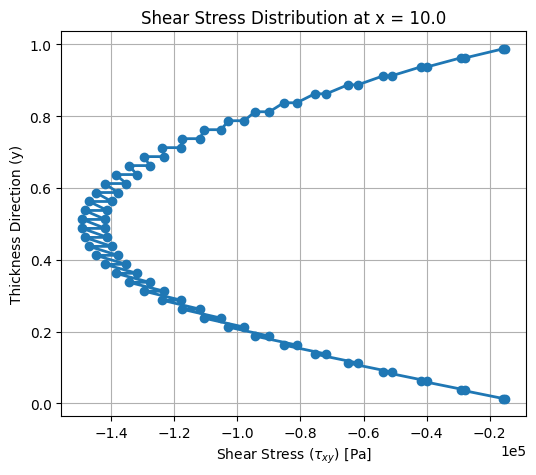

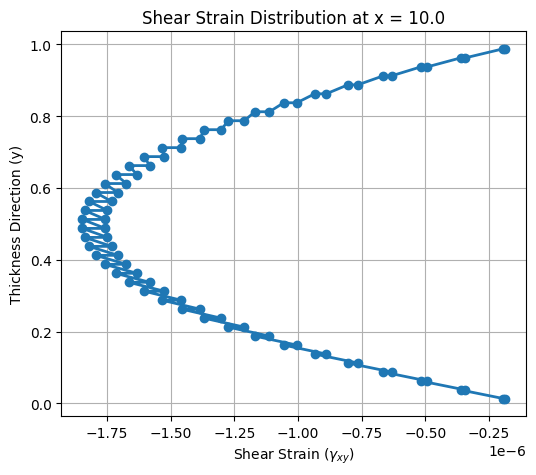

In [12]:
Lx = 20
Ly = 1

nodes, elements, dx, dy = generate_mesh(
    Lx,
    Ly,
    nx=40,
    ny=40
)

# Extract only displacement vector
U, K_global = solve_fem(nodes, elements)

plot_shear_stress_strain_through_thickness(
    nodes,
    elements,
    U,
    x_location=Lx/2,
    E=E,
    nu=nu
)


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Plot displacement field
# -------------------------------------------------

def plot_displacement_field(nodes, U, scale=1):

    # Original coordinates
    x = nodes[:,0]
    y = nodes[:,1]

    # Displacements
    ux = U[0::2]
    uy = U[1::2]

    # Deformed coordinates
    x_def = x + scale * ux
    y_def = y + scale * uy

    # Displacement magnitude
    displacement_mag = np.sqrt(ux**2 + uy**2)

    # Plot
    plt.figure(figsize=(8,5))

    scatter = plt.scatter(
        x_def,
        y_def,
        c=displacement_mag,
        cmap='jet'
    )

    plt.colorbar(scatter, label='Displacement Magnitude')

    plt.xlabel("X")

    plt.ylabel("Y")

    plt.title("Displacement Field")

    plt.axis('equal')

    plt.grid(True)

    plt.show()

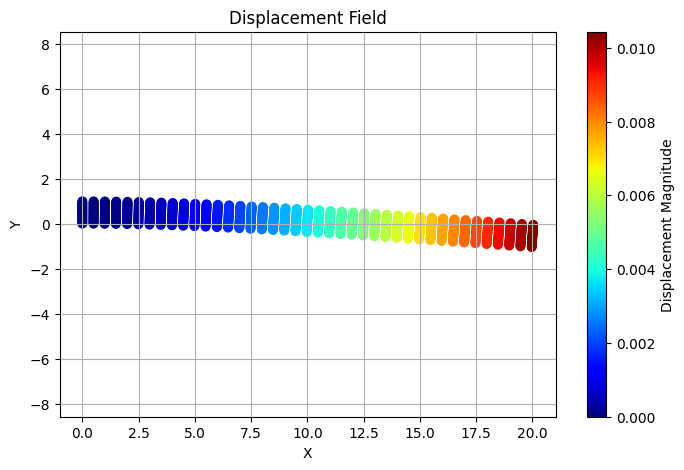

In [14]:
plot_displacement_field(nodes, U, scale=100)